In [1]:
%reload_ext autoreload
%autoreload 2

import pickle
import matplotlib.pyplot as plt
import numpy as np
import healpy as hp
import json
from scipy import interpolate

import sys
sys.path.append("..")

from utils.validation import roc_finite_sample_band

import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc_file("../../nptf-test/production/matplotlibrc")

In [2]:
from models.np_model import NPModel
import jax.numpy as jnp
from models.scd import dnds
import jax
from likelihoods.npll_jax import log_like_np
from einops import repeat
from tqdm import tqdm
from scipy.stats import chi2

/n/home07/yitians/.conda/envs/torch/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
data_s = np.load('../outputs/sims/base23fix_deltapsf_n100.npy')
mask_roi = np.load('mask_roi.npy')
mask_norm = np.load('mask_norm.npy')
data_full = data_s
data_full[:, mask_roi] = 0
data_in = jnp.asarray(data_full, dtype=jnp.int32)

m = NPModel(data=data_in[0], psf_tag='delta')
print(m.k_max)

Number of pixels in ROI: 6839
Using psf: delta
Max photon count is 118
118


In [14]:
def model(self, data, vd, Sps_gce, Sps_dsk):
    
    # Get mixed pib template
    theta_pib = jnp.array(vd['theta_pib'])
    temp_pib = jnp.sum(theta_pib[:, None] * self.pib, 0)

    # Get mixed ics template
    theta_ics = jnp.array(vd['theta_ics'])
    temp_ics = jnp.sum(theta_ics[:, None] * self.ics, 0)

    S_gce = vd['S_gce']
        
    temps = [self.temp_iso, self.temp_bub, self.temp_psc, temp_pib, temp_ics]
    temp_labels = ["iso", "bub", "psc", "pib", "ics"]
            
    mu = jnp.zeros_like(data)
    
    for temp, temp_label in zip(temps, temp_labels):
        
        S_temp = vd["S_{}".format(temp_label)]
        
        if temp_label in ["pib"]:
            
            temp_pib_mod = jnp.zeros_like(data)
            for ii in range(len(self.Ylm_temps)):
                Alm = 0.
                temp_pib_mod += Alm * self.Ylm_temps[ii]
            
            temp_pib_mod = (1. + temp_pib_mod) * temp
            
            A_temp = S_temp / jnp.mean(temp_pib_mod[~self.normalization_mask])
            mu += A_temp * temp_pib_mod  
        else:
            A_temp = S_temp / jnp.mean(temp[~self.normalization_mask])
            mu += A_temp * temp     
                                        
    gamma_ps = vd["gamma_ps"]
    gamma_poiss = vd["gamma_poiss"]

    temp_gce_nfw_ps = self.nfw_template.get_NFW2_template(gamma=gamma_ps) if self.non_poissonian else None
    temp_gce_nfw_poiss = self.nfw_template.get_NFW2_template(gamma=gamma_poiss)
        

    zs = vd["zs"]
    C = vd["C"]
    temp_dsk = self.disk_template.get_template(zs=zs, C=C)
            
    f_bulge_ps = vd["f_bulge_ps"]
    f_bulge_poiss = vd["f_bulge_poiss"]
    
    theta_bulge_poiss = jnp.array(vd["theta_bulge_poiss"])
    temp_bulge = jnp.sum(theta_bulge_poiss[:, None] * self.bulge_templates, 0)
    
    # Normalize to same mean
    A_gce_nfw = S_gce / jnp.mean(temp_gce_nfw_poiss[~self.normalization_mask])
    A_gce_bulge = S_gce / jnp.mean(temp_bulge[~self.normalization_mask])
    temp_gce_poiss = (1 - f_bulge_poiss) * A_gce_nfw * temp_gce_nfw_poiss \
                        + f_bulge_poiss * A_gce_bulge * temp_bulge
    
    A_gce = S_gce / jnp.mean(temp_gce_poiss[~self.normalization_mask])
    mu += A_gce * temp_gce_poiss
    
    if self.non_poissonian:
        # Get mixed bulge template
        theta_bulge_ps = jnp.array(vd["theta_bulge_ps"])
        temp_bulge = jnp.sum(theta_bulge_ps[:, None] * self.bulge_templates, 0)

        # Normalize to same mean
        A_gce_nfw = 1 / jnp.mean(temp_gce_nfw_ps[~self.normalization_mask])
        A_gce_bulge = 1 / jnp.mean(temp_bulge[~self.normalization_mask])

        # Get hybrid template
        temp_gce_ps = (1 - f_bulge_ps) * A_gce_nfw * temp_gce_nfw_ps + f_bulge_ps * A_gce_bulge * temp_bulge

        npt_compressed = jnp.array([temp_gce_ps, temp_dsk])

        theta = []    

        for ips, ps in enumerate(["gce", "dsk"]):

            # Sps = vd["Sps_{}".format(ps)]
            Sps = Sps_gce if ps == "gce" else Sps_dsk

            n1 = vd["n1_{}".format(ps)]
            n2 = vd["n2_{}".format(ps)]
            n3 = vd["n3_{}".format(ps)]
            sb1 = vd["sb1_{}".format(ps)]
            lambda_s = vd["lambdas_{}".format(ps)]

            theta_tmp = jnp.array([1., n1, n2, n3, sb1, lambda_s * sb1])

            s_ary = jnp.logspace(-1., 2., 1000)
            dnds_ary = dnds(s_ary, theta_tmp)

            A = Sps / jnp.mean(npt_compressed[ips][~self.normalization_mask] * jnp.trapz(s_ary * dnds_ary, s_ary))

            theta.append([A, n1, n2, n3, sb1, lambda_s * sb1])

        theta = jnp.array(theta)
            
    # Pad the last exposure region so that all are the same size
    exp_lens = [len(self.expreg_indices[i]) for i in range(len(self.expreg_indices))]
    n_pad = exp_lens[0] - exp_lens[-1]
    
    expreg_indices = jnp.zeros_like(self.expreg_indices)
    expreg_indices = expreg_indices.at[:-1].set(self.expreg_indices[:-1])
    expreg_indices = expreg_indices.at[-1].set(jnp.pad(self.expreg_indices[-1], (0, n_pad)))

    log_like_np_exp_vmapped = jax.vmap(log_like_np, in_axes=(0, 0, 1, 0, None, None, None, None))
            
    # Get relevant arrays for different exposure regions
    mu_batch = mu[~self.mask_roi][jnp.array(expreg_indices)]
    if self.non_poissonian:
        npt_compressed_batch = npt_compressed[:, ~self.mask_roi][:, jnp.array(expreg_indices)]
    data_batch = data[~self.mask_roi][jnp.array(expreg_indices)]
    
    exposure_multiplier = self.exposure_means_list / self.exposure_mean
    
    # Scale non-Poissonian parameters (norm divided by exposure ratio, breaks multiplied)
    if self.non_poissonian:
        theta = repeat(theta, "n_ps n_param -> n_exp n_ps n_param", n_exp=len(expreg_indices))
        theta = theta.at[:, :, 0].set(theta[:, :, 0] / exposure_multiplier[:, None])
        theta = theta.at[:, :, -1].set(theta[:, :, -1] * exposure_multiplier[:, None])
        theta = theta.at[:, :, -2].set(theta[:, :, -2] * exposure_multiplier[:, None])
    
    log_like_exp = log_like_np_exp_vmapped(theta, mu_batch, npt_compressed_batch, data_batch, self.f_ary, self.df_rho_ary, self.k_max, len(expreg_indices[0]))
    log_like = jnp.sum(log_like_exp)
    return log_like

jmodel = jax.jit(model, static_argnums=(0,))

In [67]:
vd = json.load(open('truth_dict_base230927.json', 'r'))
Sps_gce_arr = np.linspace(vd['Sps_gce'] - 0.5, vd['Sps_gce'] + 0.5, 30)
Sps_dsk_arr = np.linspace(vd['Sps_dsk'] - 0.5, vd['Sps_dsk'] + 0.5, 30)
ll_sss = []
for i in range(30):
    ll_ss = []
    for Sps_gce in tqdm(Sps_gce_arr):
        ll_s = []
        for Sps_dsk in Sps_dsk_arr:
            vd['Sps_gce'] = Sps_gce
            vd['Sps_dsk'] = Sps_dsk
            m.k_max = int(jnp.max(data_in[i]))
            ll_s.append(jmodel(m, data_in[i], vd, Sps_gce, Sps_dsk))
        ll_ss.append(ll_s)
    ll_sss.append(ll_ss)
ll_sss = np.array(ll_sss)

100%|██████████| 30/30 [00:10<00:00,  2.99it/s]


In [17]:
def ctlevel(dof, confidence_level):
    return - 0.5 * chi2.ppf(confidence_level, dof)

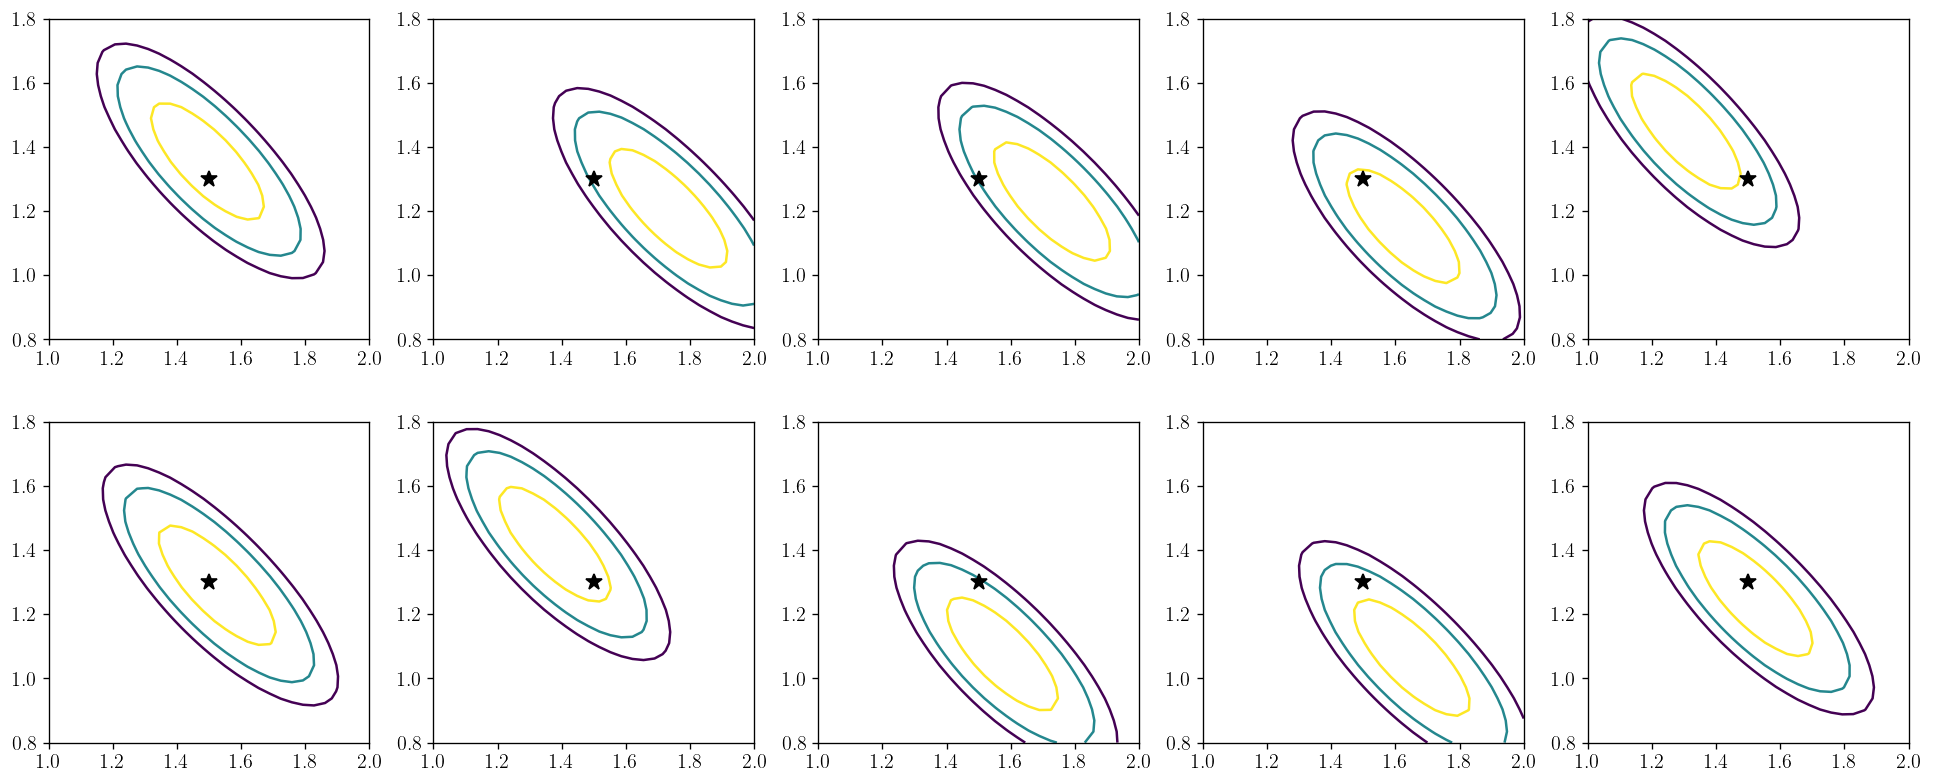

In [18]:
fig, axs = plt.subplots(2, 5, figsize=(20, 8))
vd_o = json.load(open('truth_dict_base230927.json', 'r'))
for iax, ax in enumerate(axs.flat):
    ll_plot = ll_sss[iax] - np.max(ll_sss[iax])
    ax.contour(Sps_gce_arr, Sps_dsk_arr, ll_plot, levels=[ctlevel(2, x) for x in [0.99, 0.95, 0.68]])
    ax.plot(vd_o['Sps_gce'], vd_o['Sps_dsk'], 'k*', ms=10)
    ax.set(aspect=1)

In [25]:
def find_levels(hist_counts, levels=[0.99, 0.95, 0.68]):
    hist_counts_flat = hist_counts.flatten()
    hist_counts_sorted = np.sort(hist_counts_flat)[::-1]
    hist_counts_cumsum = np.cumsum(hist_counts_sorted)
    hist_counts_cumsum /= hist_counts_cumsum[-1]
    levels_vals = [hist_counts_sorted[np.argmin(np.abs(hist_counts_cumsum - x))] for x in levels]
    return levels_vals

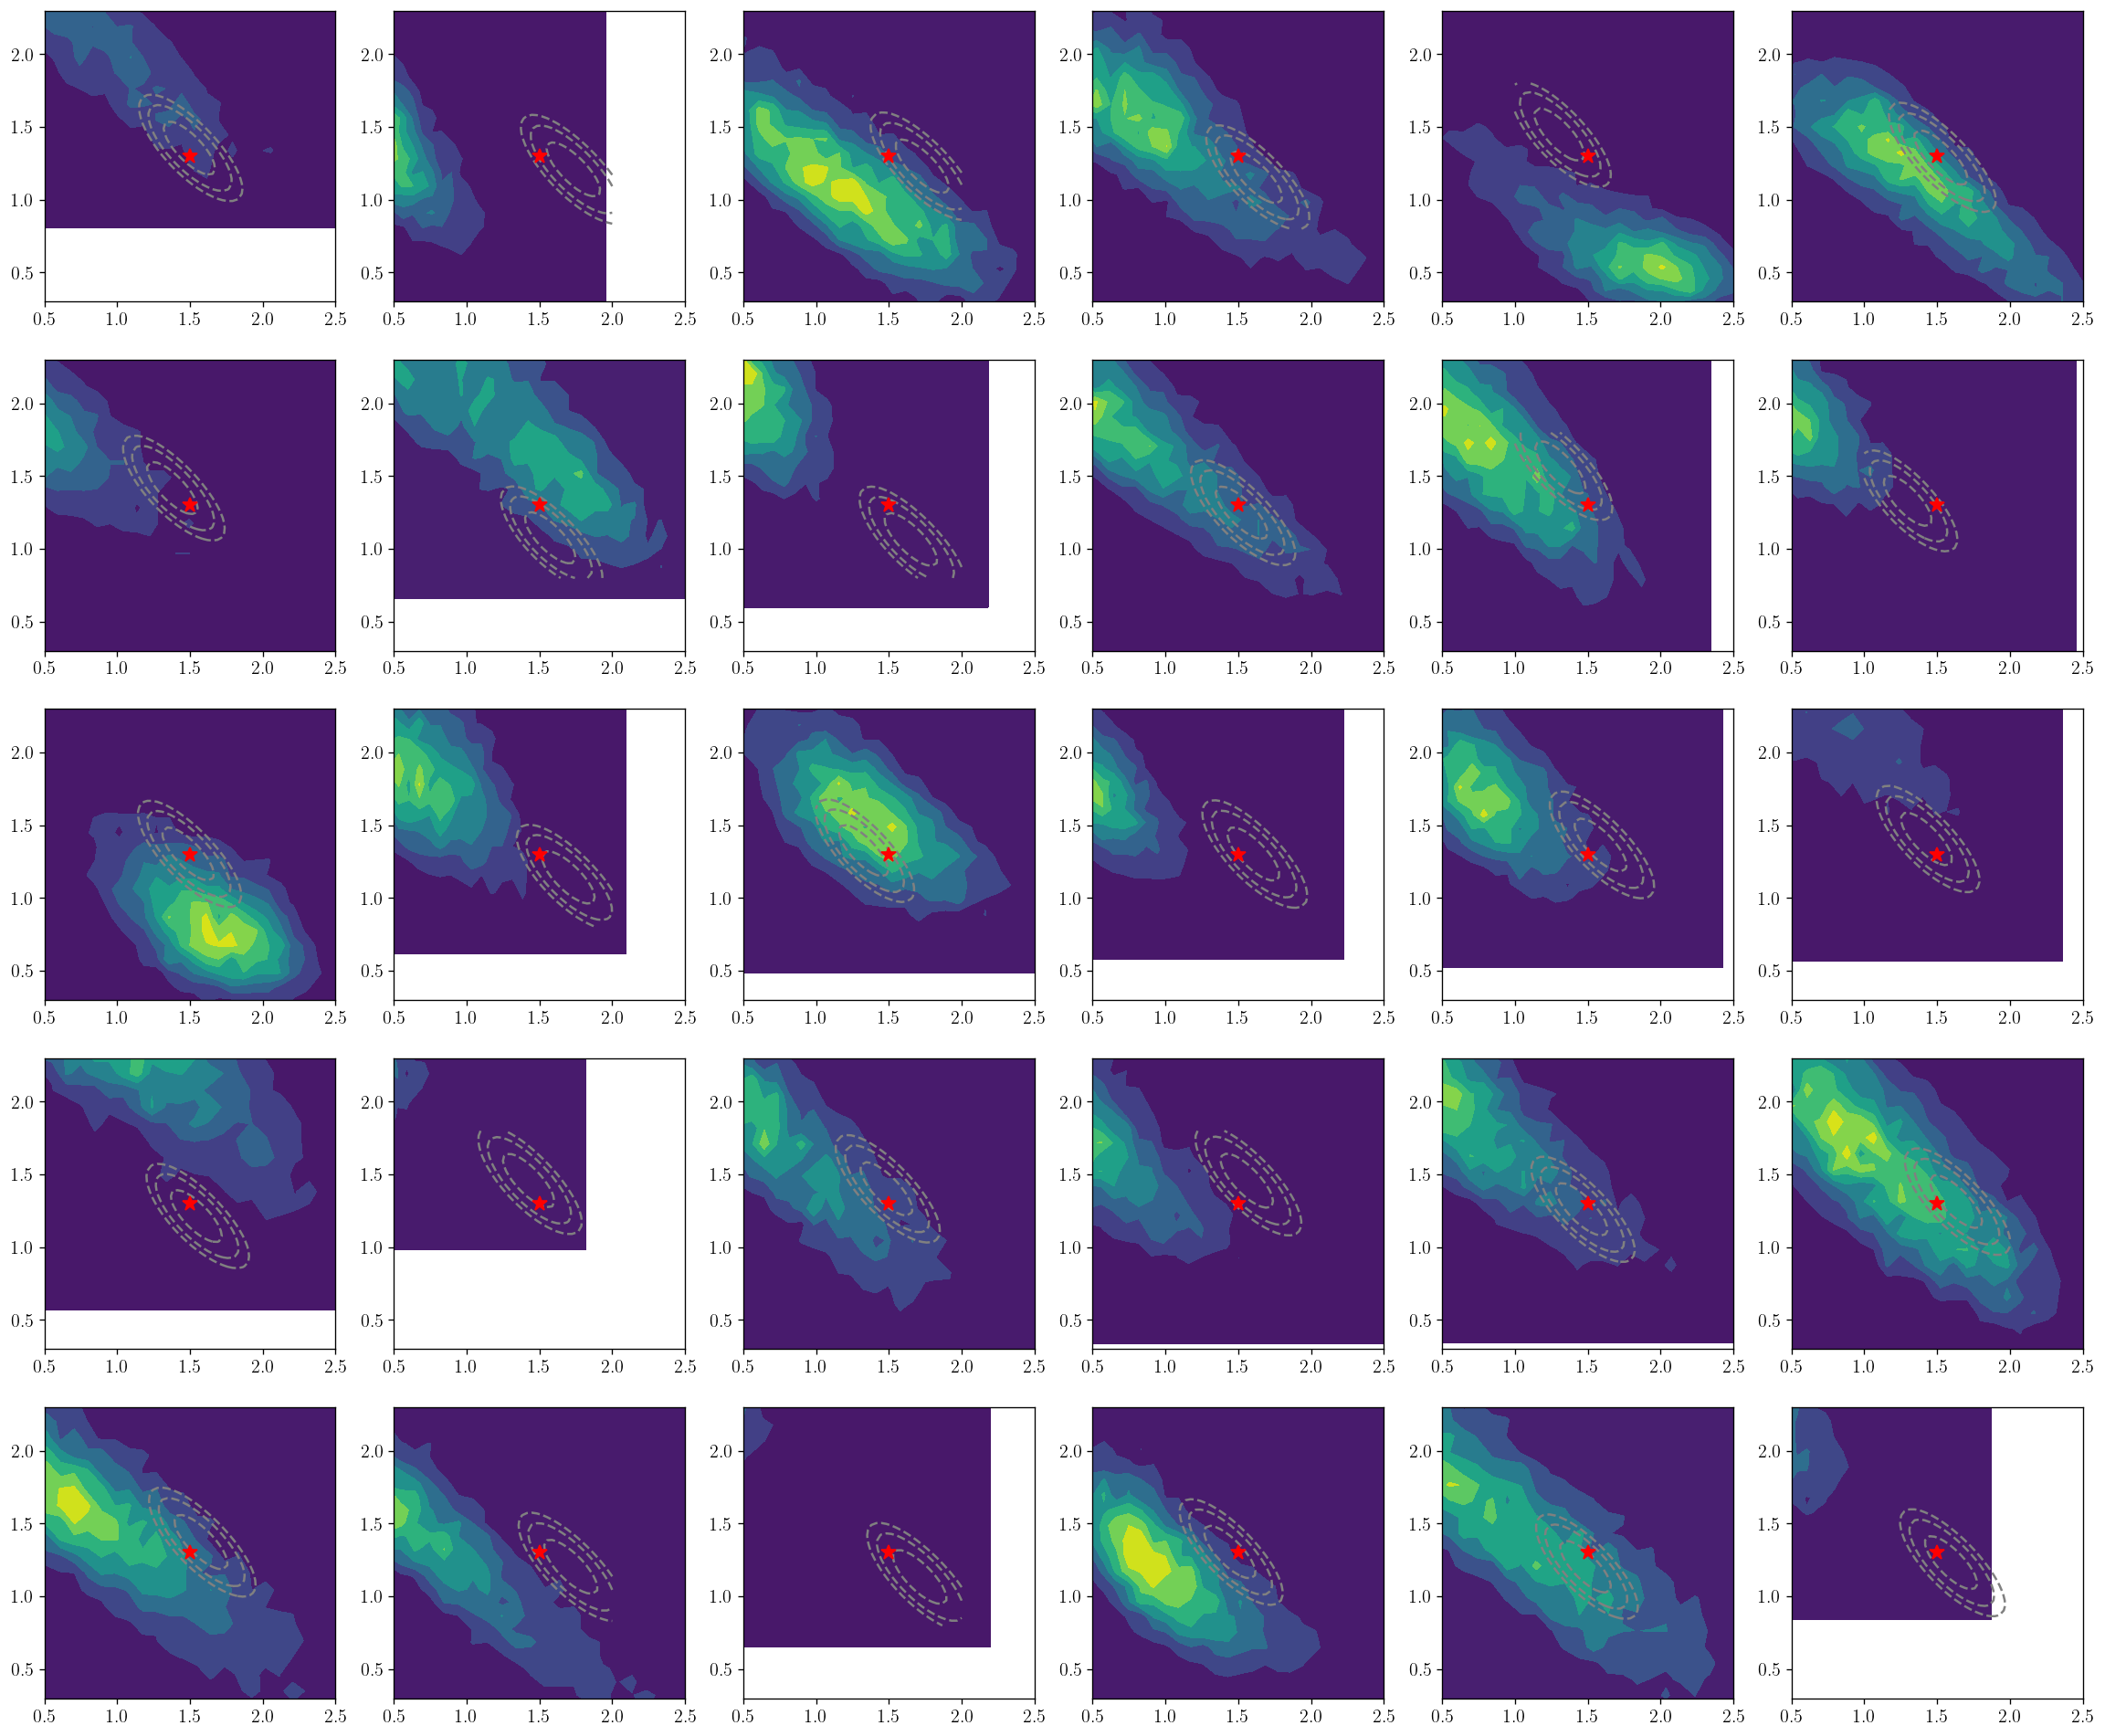

In [68]:
fig, axs = plt.subplots(5, 6, figsize=(24, 20))
vd_o = json.load(open('truth_dict_base230927.json', 'r'))
for iax, ax in enumerate(axs.flat):

    # plot samples
    # s = pickle.load(open(f"../outputs/fit/pthmc_Dbase23fix_deltapsf_Mbase23fix_deltapsf/i{iax}_n10000_ns2000.p", 'rb'))
    s = pickle.load(open(f"/n/holylabs/LABS/iaifi_lab/Users/yitians/fermi/fermi-prob-prog/outputs/fit/hmcnt_Dbase23fix_Mbase23fix_svi1e-4/i{iax}_n10000_ns10000.p", 'rb'))

    x_s = s['Sps_gce']
    y_s = s['Sps_dsk']
    bins = [np.linspace(vd['Sps_gce'] - 0.5, vd['Sps_gce'] + 0.5, 30), np.linspace(vd['Sps_dsk'] - 0.5, vd['Sps_dsk'] + 0.5, 30)]
    counts, xedges, yedges = np.histogram2d(x_s, y_s, bins=30, density=True)
    xc = 0.5 * (xedges[1:] + xedges[:-1])
    yc = 0.5 * (yedges[1:] + yedges[:-1])
    # levels = find_levels(counts)
    ax.contourf(xc, yc, counts.T)

    # plot LL
    ll_plot = ll_sss[iax] - np.max(ll_sss[iax])
    ax.contour(Sps_gce_arr, Sps_dsk_arr, ll_plot, levels=[ctlevel(2, x) for x in [0.99, 0.95, 0.68]], colors='gray')

    # plot truth
    ax.plot(vd_o['Sps_gce'], vd_o['Sps_dsk'], 'r*', ms=10)

    ax.set(xlim=[vd_o['Sps_gce'] - 1, vd_o['Sps_gce'] + 1], ylim=[vd_o['Sps_dsk'] - 1, vd_o['Sps_dsk'] + 1])

# Test transposed-ness of contourf and imshow

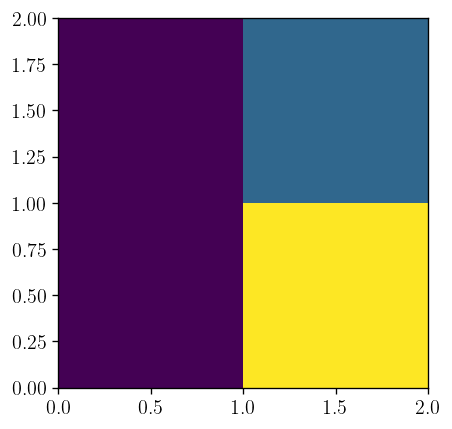

In [47]:
x_bins = np.array([0, 1, 2])
y_bins = np.array([0, 1, 2])
x_centers = 0.5 * (x_bins[1:] + x_bins[:-1])
y_centers = 0.5 * (y_bins[1:] + y_bins[:-1])
x_s = np.array([1.5, 1.5, 1.5, 1.5])
y_s = np.array([0.5, 0.5, 0.5, 1.5])
counts, xedges, yedges = np.histogram2d(x_s, y_s, bins=[x_bins, y_bins], density=True)
# plt.contourf(x_centers, y_centers, counts.T)
plt.imshow(counts.T, origin='lower', extent=[x_bins[0], x_bins[-1], y_bins[0], y_bins[-1]])

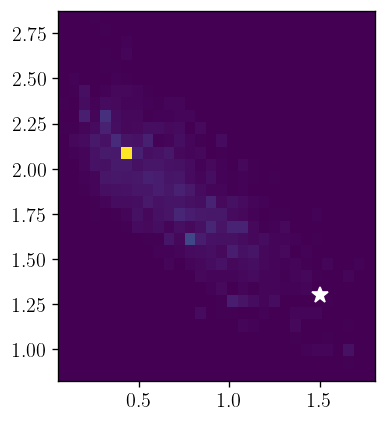

In [53]:
s = pickle.load(open(f"../outputs/fit/pthmc_Dbase23fix_deltapsf_Mbase23fix_deltapsf/i{3}_n10000_ns2000.p", 'rb'))
x_s = s['Sps_gce']
y_s = s['Sps_dsk']
counts, xedges, yedges = np.histogram2d(x_s, y_s, bins=30, density=True)
plt.imshow(counts.T, origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]])
plt.plot(vd_o['Sps_gce'], vd_o['Sps_dsk'], 'w*', ms=10)

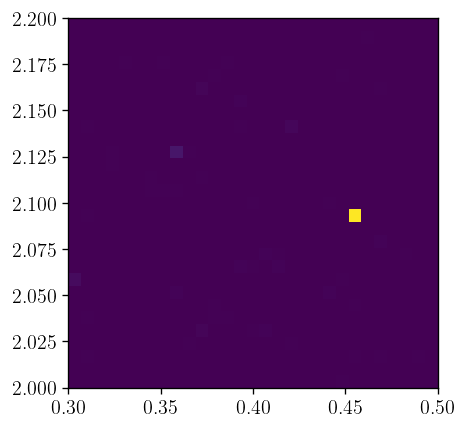

In [57]:
s = pickle.load(open(f"../outputs/fit/pthmc_Dbase23fix_deltapsf_Mbase23fix_deltapsf/i{3}_n10000_ns2000.p", 'rb'))
x_s = s['Sps_gce']
y_s = s['Sps_dsk']
bins = [np.linspace(0.3, 0.5, 30), np.linspace(2.0, 2.2, 30)]
counts, xedges, yedges = np.histogram2d(x_s, y_s, bins=bins, density=False)
plt.imshow(counts.T, origin='lower', extent=[0.3, 0.5, 2.0, 2.2])
# plt.plot(vd_o['Sps_gce'], vd_o['Sps_dsk'], 'w*', ms=10)

(array([ 334., 1483., 2542., 1629., 1601., 1281.,  580.,  309.,  137.,
         104.]),
 array([0.05390416, 0.22933063, 0.40475711, 0.58018359, 0.75561006,
        0.93103654, 1.10646302, 1.28188949, 1.45731597, 1.63274244,
        1.80816892]),
 <BarContainer object of 10 artists>)

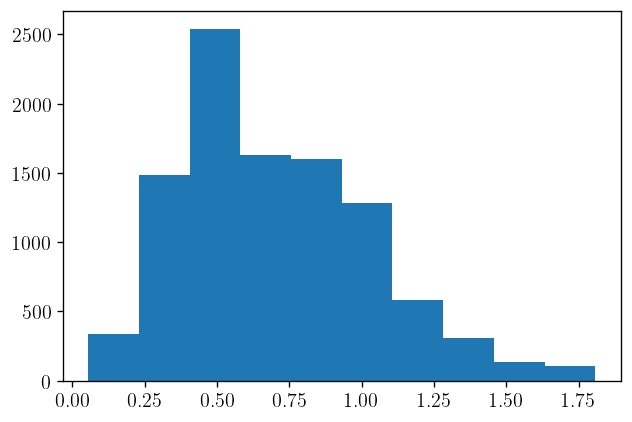

In [61]:
plt.hist(x_s)